# ElasticNet: from scratch vs. scikit-learn

Fits `ElasticNetGD` (mini-batch gradient descent, plain numpy) and scikit-learn's own `ElasticNet` on the same preprocessed data and target, alongside the plain-regression/Ridge/Lasso baselines from `1_linear_regression.ipynb`/`2_regularized_regression.ipynb` -- per `docs/superpowers/specs/2026-09-06-elastic-net-regression-design.md`.

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split

from ames_price.constants import NOMINAL_COLS, NUMERIC_COLS, ORDINAL_COLS
from ames_price.models.elastic_net_gd import ElasticNetGD
from ames_price.models.lasso_gd import LassoGD
from ames_price.models.linear_regression import LinearRegressionGD
from ames_price.models.ridge_gd import RidgeGD
from ames_price.pipeline import build_pipeline

FEATURE_COLS = NUMERIC_COLS + ORDINAL_COLS + NOMINAL_COLS

## Load data, drop outliers, build the target, split before fitting

Same leak-free setup as notebooks 1 and 2: `Id` 524/1299 dropped, target is `log_sale_price`, pipeline `fit_transform` on the training split only, `transform` on validation.

In [19]:
df_train = pd.read_csv("../../data/train.csv")
df_train = df_train[~df_train["Id"].isin([524, 1299])]

X_raw = df_train[FEATURE_COLS]
y = np.log1p(df_train["SalePrice"]).to_numpy()

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_raw, y, test_size=0.2, random_state=42
)

pipeline = build_pipeline()
X_train = pipeline.fit_transform(X_train_raw).to_numpy()
X_val = pipeline.transform(X_val_raw).to_numpy()
X_train.shape, X_val.shape

((1166, 236), (292, 236))

## Grid sweep over (alpha, l1_ratio)

A 2D grid, narrower than Ridge/Lasso's 9-point 1D sweep since there are now two hyperparameters (5 alphas x 5 l1_ratios = 25 combinations). As with Ridge/Lasso, `ElasticNetGD`'s and sklearn `ElasticNet`'s alpha/l1_ratio are not expected to mean exactly the same shrinkage strength -- comparison happens at the level of each model's own best validation RMSE.

In [20]:
alphas = np.logspace(-3, 1, 5)
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


en_gd_rmse = np.zeros((len(alphas), len(l1_ratios)))
en_sk_rmse = np.zeros((len(alphas), len(l1_ratios)))

for i, a in enumerate(alphas):
    for j, r in enumerate(l1_ratios):
        en_gd = ElasticNetGD(
            learning_rate=0.01, batch_size=32, n_epochs=300,
            alpha=a, l1_ratio=r, random_state=42,
        )
        en_gd.fit(X_train, y_train)
        en_gd_rmse[i, j] = rmse(y_val, en_gd.predict(X_val))

        en_sk = ElasticNet(alpha=a, l1_ratio=r)
        en_sk.fit(X_train, y_train)
        en_sk_rmse[i, j] = rmse(y_val, en_sk.predict(X_val))

## Validation RMSE heatmap

The 2D analogue of notebook 2's `semilogx` line plot -- lightest (yellow) cell is each model's best (alpha, l1_ratio) region on this holdout split; darkest (purple) is worst.

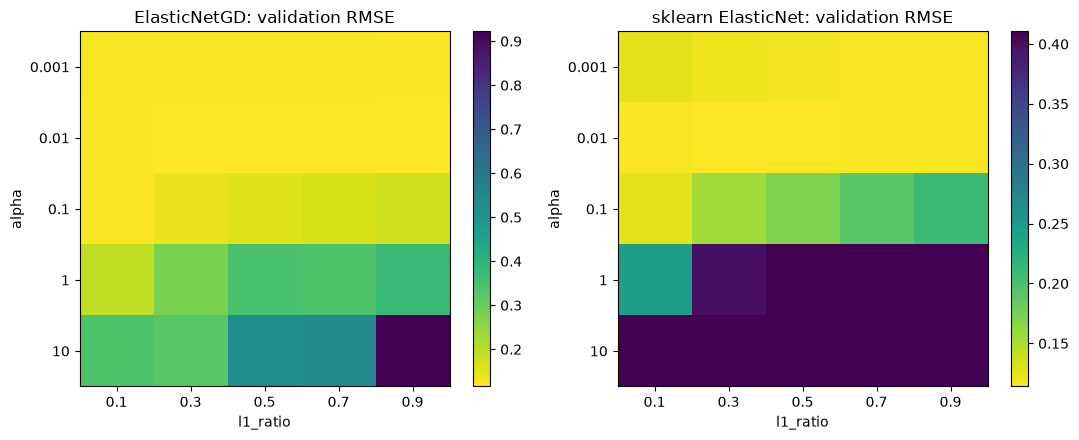

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, data, title in [
    (axes[0], en_gd_rmse, "ElasticNetGD"),
    (axes[1], en_sk_rmse, "sklearn ElasticNet"),
]:
    im = ax.imshow(data, aspect="auto", cmap="viridis_r")
    ax.set_xticks(range(len(l1_ratios)))
    ax.set_xticklabels(l1_ratios)
    ax.set_yticks(range(len(alphas)))
    ax.set_yticklabels([f"{a:.4g}" for a in alphas])
    ax.set_xlabel("l1_ratio")
    ax.set_ylabel("alpha")
    ax.set_title(f"{title}: validation RMSE")
    fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

## Refit each model at its own best (alpha, l1_ratio)

The plain/Ridge/Lasso baselines are refit here too, exactly as in `2_regularized_regression.ipynb`, so this notebook stands on its own with the full model roster.

In [22]:
best_en_gd_idx = np.unravel_index(np.argmin(en_gd_rmse), en_gd_rmse.shape)
best_en_sk_idx = np.unravel_index(np.argmin(en_sk_rmse), en_sk_rmse.shape)
best_en_gd_alpha, best_en_gd_l1_ratio = (
    alphas[best_en_gd_idx[0]], l1_ratios[best_en_gd_idx[1]],
)
best_en_sk_alpha, best_en_sk_l1_ratio = (
    alphas[best_en_sk_idx[0]], l1_ratios[best_en_sk_idx[1]],
)

en_gd_best = ElasticNetGD(
    learning_rate=0.01, batch_size=32, n_epochs=300,
    alpha=best_en_gd_alpha, l1_ratio=best_en_gd_l1_ratio,
    random_state=42,
)
en_gd_best.fit(X_train, y_train)

en_sk_best = ElasticNet(
    alpha=best_en_sk_alpha, l1_ratio=best_en_sk_l1_ratio,
)
en_sk_best.fit(X_train, y_train)

# best alphas below are copied from 2_regularized_regression.ipynb's
# own executed output (its alpha sweep), not re-swept here.
ridge_gd_best = RidgeGD(
    learning_rate=0.01, batch_size=32, n_epochs=300, alpha=0.03162,
    random_state=42,
)
ridge_gd_best.fit(X_train, y_train)

ridge_sk_best = Ridge(alpha=31.62)
ridge_sk_best.fit(X_train, y_train)

lasso_gd_best = LassoGD(
    learning_rate=0.01, batch_size=32, n_epochs=300, alpha=0.01,
    random_state=42,
)
lasso_gd_best.fit(X_train, y_train)

lasso_sk_best = Lasso(alpha=0.003162)
lasso_sk_best.fit(X_train, y_train)

linreg_gd_baseline = LinearRegressionGD(
    learning_rate=0.01, batch_size=32, n_epochs=300, random_state=42
)
linreg_gd_baseline.fit(X_train, y_train)

linreg_sk_baseline = LinearRegression()
linreg_sk_baseline.fit(X_train, y_train)

MODELS = [
    ("LinearRegressionGD (baseline)", linreg_gd_baseline),
    ("sklearn LinearRegression (baseline)", linreg_sk_baseline),
    ("RidgeGD (alpha=0.03162)", ridge_gd_best),
    ("sklearn Ridge (alpha=31.62)", ridge_sk_best),
    ("LassoGD (alpha=0.01)", lasso_gd_best),
    ("sklearn Lasso (alpha=0.003162)", lasso_sk_best),
    (
        f"ElasticNetGD (alpha={best_en_gd_alpha:.4g}, "
        f"l1_ratio={best_en_gd_l1_ratio})",
        en_gd_best,
    ),
    (
        f"sklearn ElasticNet (alpha={best_en_sk_alpha:.4g}, "
        f"l1_ratio={best_en_sk_l1_ratio})",
        en_sk_best,
    ),
]

## Metrics table

RMSE in log space is the metric that actually matters (matches the Kaggle scoring); RMSE in dollar space (via `expm1`) and MAPE are for human-readable intuition.

In [23]:
metrics_rows = []
for name, model in MODELS:
    preds_log = model.predict(X_val)
    preds_dollars = np.expm1(preds_log)
    actual_dollars = np.expm1(y_val)
    mape = mean_absolute_percentage_error(actual_dollars, preds_dollars)
    metrics_rows.append(
        {
            "model": name,
            "RMSE (log space)": rmse(y_val, preds_log),
            "RMSE (dollars, intuition only)": rmse(
                actual_dollars, preds_dollars
            ),
            "R^2": r2_score(y_val, preds_log),
            "MAE (log space)": mean_absolute_error(y_val, preds_log),
            "MAPE (dollars, % of actual price)": 100 * mape,
        }
    )

metrics_df = pd.DataFrame(metrics_rows).set_index("model")
metrics_df

,RMSE (log space),"RMSE (dollars, intuition only)",R^2,MAE (log space),"MAPE (dollars, % of actual price)"
model,,,,,
LinearRegressionGD (baseline),0.129316,22150.880483,0.900801,0.089412,9.112843
sklearn LinearRegression (baseline),0.131956,21996.366199,0.896710,0.089983,9.127959
RidgeGD (alpha=0.03162),0.123382,21625.061472,0.909696,0.087814,9.058205
sklearn Ridge (alpha=31.62),0.121564,21327.627668,0.912337,0.086978,8.962231
LassoGD (alpha=0.01),0.116306,19422.823774,0.919757,0.082283,8.517492
sklearn Lasso (alpha=0.003162),0.113262,19109.246971,0.923902,0.081730,8.410648
"ElasticNetGD (alpha=0.01, l1_ratio=0.7)",0.115441,19429.647187,0.920947,0.081893,8.461866
"sklearn ElasticNet (alpha=0.01, l1_ratio=0.3)",0.113979,19287.215011,0.922935,0.082237,8.466782


## Coefficient sparsity comparison

Extends `2_regularized_regression.ipynb`'s bar chart with ElasticNet -- expected to sit between Ridge (least sparse) and Lasso (most sparse), illustrating the mixed penalty's intermediate feature-selection behavior against the pipeline's 236-column, rank-207 design (`preprocessing_check.ipynb`).

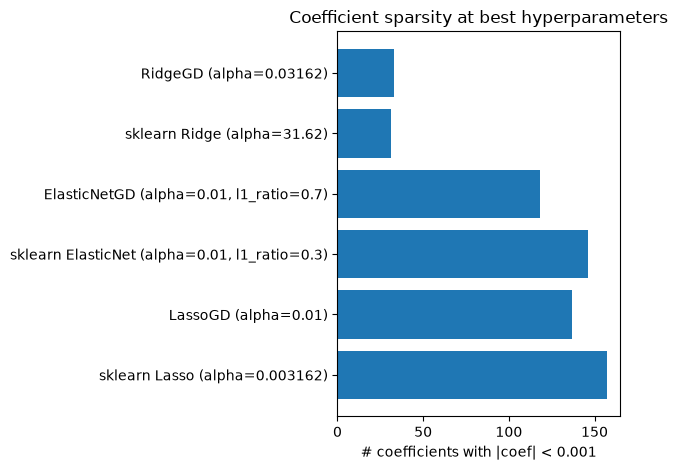

RidgeGD (alpha=0.03162): 33 / 236 coefficients near zero
sklearn Ridge (alpha=31.62): 31 / 236 coefficients near zero
ElasticNetGD (alpha=0.01, l1_ratio=0.7): 118 / 236 coefficients near zero
sklearn ElasticNet (alpha=0.01, l1_ratio=0.3): 146 / 236 coefficients near zero
LassoGD (alpha=0.01): 137 / 236 coefficients near zero
sklearn Lasso (alpha=0.003162): 157 / 236 coefficients near zero


In [24]:
threshold = 1e-3
sparsity_models = [
    ("RidgeGD (alpha=0.03162)", ridge_gd_best.coef_),
    ("sklearn Ridge (alpha=31.62)", ridge_sk_best.coef_.ravel()),
    (
        f"ElasticNetGD (alpha={best_en_gd_alpha:.4g}, "
        f"l1_ratio={best_en_gd_l1_ratio})",
        en_gd_best.coef_,
    ),
    (
        f"sklearn ElasticNet (alpha={best_en_sk_alpha:.4g}, "
        f"l1_ratio={best_en_sk_l1_ratio})",
        en_sk_best.coef_.ravel(),
    ),
    ("LassoGD (alpha=0.01)", lasso_gd_best.coef_),
    ("sklearn Lasso (alpha=0.003162)", lasso_sk_best.coef_.ravel()),
]

names = [name for name, _ in sparsity_models]
zero_counts = [
    int(np.sum(np.abs(coef) < threshold)) for _, coef in sparsity_models
]

plt.barh(names, zero_counts)
plt.xlabel(f"# coefficients with |coef| < {threshold}")
plt.title("Coefficient sparsity at best hyperparameters")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

n_features = ridge_gd_best.coef_.shape[0]
for name, count in zip(names, zero_counts, strict=True):
    print(f"{name}: {count} / {n_features} coefficients near zero")

## Summary

ElasticNet did not come out on top overall. On the GD side, `ElasticNetGD` (alpha=0.01, l1_ratio=0.7) edges past `LassoGD` (alpha=0.01) on validation RMSE (log space) -- 0.1154 vs. 0.1163 -- but on the sklearn side the ordering flips: sklearn's `ElasticNet` (alpha=0.01, l1_ratio=0.3) comes in at 0.1140, while sklearn's own `Lasso` (alpha=0.003162) is still lower at 0.1133. So the "elastic net should do at least as well as pure Lasso" intuition holds for the from-scratch implementation but not for sklearn's, on this grid.

The sparsity comparison tells a similar story: within each model family, ElasticNet does sit between Ridge and Lasso on the number of near-zero coefficients -- `RidgeGD` 33, `ElasticNetGD` 118, `LassoGD` 137 (all out of 236); sklearn Ridge 31, sklearn ElasticNet 146, sklearn Lasso 157. But that ordering doesn't hold strictly across families: sklearn ElasticNet's 146 near-zero coefficients actually exceed `LassoGD`'s 137, even though sklearn ElasticNet correctly sits below sklearn's own Lasso (157). "Between Ridge and Lasso" is a within-family statement, not a universal one.

One more caveat: this notebook's grid (`np.logspace(-3, 1, 5)`, 5 alphas) is coarser than notebook 2's Ridge/Lasso sweep (9 alphas), so sklearn Lasso's own best alpha from notebook 2 (0.003162) isn't a point on this grid at all. Some of the small RMSE gap between sklearn ElasticNet and sklearn Lasso above may reflect that resolution difference rather than a real quality gap between the two.